# Tahap 4 — Case Solution Reuse
## CBR Sistem Analisis Putusan Narkotika

**Tujuan:** Gunakan putusan lama sebagai dasar solusi untuk kasus baru.

**Langkah:**
1. Ekstrak solusi (amar putusan) dari kasus top-k
2. Agregasi solusi dengan dua metode:
   - **Majority Vote:** pilih label yang paling banyak muncul di top-k
   - **Weighted Similarity:** bobot berdasarkan cosine similarity score
3. Demo dengan 5 kasus baru
4. Simpan hasil ke `data/results/predictions.csv`

## 4.0 Setup & Load Artefacts

In [1]:
import os, pickle, json
import pandas as pd
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from collections import Counter

ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
os.chdir(ROOT)
os.makedirs('data/results', exist_ok=True)

df           = pd.read_csv('data/processed/cases.csv', encoding='utf-8-sig')
vectorizer   = pickle.load(open('models/tfidf_vectorizer.pkl','rb'))
clf          = pickle.load(open('models/svm_classifier.pkl','rb'))
le           = pickle.load(open('models/label_encoder.pkl','rb'))
tfidf_matrix = sp.load_npz('models/tfidf_matrix.npz')

print('✓ Semua artefakt ter-load')
print(f'  Dataset: {len(df)} kasus')
print(f'  TF-IDF : {tfidf_matrix.shape}')

✓ Semua artefakt ter-load
  Dataset: 35 kasus
  TF-IDF : (35, 805)


## 4.1 Bangun Case Solutions Dictionary

In [2]:
# Map case_id → solusi (amar putusan + label)
case_solutions = {}
for _, row in df.iterrows():
    case_solutions[int(row['case_id'])] = {
        'amar_putusan'  : str(row['amar_putusan']),
        'label_putusan' : str(row['label_putusan']),
        'pasal'         : str(row['pasal']),
        'jenis_narkoba' : str(row['jenis_narkoba']),
    }

print(f'✓ Case solutions: {len(case_solutions)} entri')
print('Contoh solusi case_id=1:')
print(json.dumps(case_solutions[1], indent=2, ensure_ascii=False))

✓ Case solutions: 35 entri
Contoh solusi case_id=1:
{
  "amar_putusan": "Menjatuhkan pidana kepada Terdakwa dengan pidana penjara 17 tahun dan denda Rp 800",
  "label_putusan": "pidana penjara",
  "pasal": "114 ayat (2) UU No.35 Tahun 2009 tentang Narkotika",
  "jenis_narkoba": "sabu-sabu"
}


## 4.2 Fungsi `retrieve` dan `predict_outcome`

In [3]:
def retrieve(query: str, k: int = 5):
    """Kembalikan top-k case_id + similarity scores."""
    q_vec    = vectorizer.transform([query.lower()])
    sims     = cosine_similarity(q_vec, tfidf_matrix).flatten()
    top_k    = np.argsort(sims)[::-1][:k]
    case_ids = [int(df.iloc[i]['case_id']) for i in top_k]
    sim_vals = sims[top_k].tolist()
    return case_ids, sim_vals


def predict_outcome(query: str, k: int = 5, method: str = 'weighted') -> dict:
    """
    Prediksi solusi untuk kasus baru berdasarkan top-k kasus mirip.

    Parameters
    ----------
    query  : str   — Deskripsi kasus baru
    k      : int   — Jumlah kasus referensi (default 5)
    method : str   — 'majority' atau 'weighted' (default 'weighted')

    Returns
    -------
    dict dengan predicted_label, representative_amar, top_k_info
    """
    top_k, sims = retrieve(query, k=k)
    solutions   = [case_solutions[cid] for cid in top_k]
    labels      = [s['label_putusan'] for s in solutions]

    if method == 'majority':
        predicted_label = Counter(labels).most_common(1)[0][0]
    else:  # weighted
        weights = {}
        for lab, sim in zip(labels, sims):
            weights[lab] = weights.get(lab, 0) + sim
        predicted_label = max(weights, key=weights.get)

    # Ambil amar putusan representatif (kasus paling mirip dengan label sesuai)
    best_idx = next((i for i, s in enumerate(solutions)
                     if s['label_putusan'] == predicted_label), 0)

    return {
        'predicted_label'   : predicted_label,
        'representative_amar': solutions[best_idx]['amar_putusan'],
        'top_5_case_ids'    : top_k,
        'top_5_similarities': [round(s,4) for s in sims],
        'top_5_labels'      : labels,
    }

print('✓ Fungsi retrieve() dan predict_outcome() siap')

✓ Fungsi retrieve() dan predict_outcome() siap


## 4.3 Perbandingan Majority Vote vs Weighted Similarity

In [4]:
test_query = 'terdakwa menyimpan 1000 gram heroin di rumahnya tanpa hak pasal 112'

result_majority  = predict_outcome(test_query, method='majority')
result_weighted  = predict_outcome(test_query, method='weighted')

print(f'Query: "{test_query}"\n')
print(f'Top-5 Case IDs  : {result_weighted["top_5_case_ids"]}')
print(f'Top-5 Labels    : {result_weighted["top_5_labels"]}')
print(f'Top-5 Sims      : {result_weighted["top_5_similarities"]}\n')
print(f'Majority Vote   → {result_majority["predicted_label"]}')
print(f'Weighted Sim    → {result_weighted["predicted_label"]}')
print(f'\nAmar Putusan (representatif):')
print(f'  {result_weighted["representative_amar"]}')

Query: "terdakwa menyimpan 1000 gram heroin di rumahnya tanpa hak pasal 112"

Top-5 Case IDs  : [31, 35, 3, 2, 22]
Top-5 Labels    : ['penjara seumur hidup', 'penjara seumur hidup', 'penjara seumur hidup', 'pidana penjara', 'penjara seumur hidup']
Top-5 Sims      : [0.2699, 0.2533, 0.2494, 0.2092, 0.2059]

Majority Vote   → penjara seumur hidup
Weighted Sim    → penjara seumur hidup

Amar Putusan (representatif):
  Menjatuhkan pidana kepada Terdakwa dengan pidana penjara seumur hidup dan denda Rp 1500


## 4.4 Demo Manual — 5 Kasus Baru

In [5]:
NEW_CASES = [
    {'query_id':'NEW-001',
     'query_text':'terdakwa ditemukan membawa sabu-sabu 3 gram dalam kantong celana oleh polisi saat razia',
     'actual_label':'pidana penjara'},
    {'query_id':'NEW-002',
     'query_text':'tersangka menyimpan 1500 gram heroin dikemas dalam paket di lemari rumahnya',
     'actual_label':'penjara seumur hidup'},
    {'query_id':'NEW-003',
     'query_text':'terdakwa menanam 10 batang pohon ganja di pekarangan belakang rumah pasal 111',
     'actual_label':'pidana penjara'},
    {'query_id':'NEW-004',
     'query_text':'permufakatan jahat terdakwa bersama rekannya mengedarkan narkotika pasal 132',
     'actual_label':'pidana penjara'},
    {'query_id':'NEW-005',
     'query_text':'terdakwa memiliki 800 gram kokain golongan I bukan tanaman untuk diedarkan tanpa izin',
     'actual_label':'penjara seumur hidup'},
]

rows = []
print(f'{"ID":<10} {"Predicted":<25} {"Actual":<25} {"Match"}')
print('-' * 75)

for nc in NEW_CASES:
    result = predict_outcome(nc['query_text'], k=5, method='weighted')
    match  = result['predicted_label'] == nc['actual_label']
    print(f"{nc['query_id']:<10} {result['predicted_label']:<25} {nc['actual_label']:<25} {'✓' if match else '✗'}")
    rows.append({
        'query_id'           : nc['query_id'],
        'query_text'         : nc['query_text'],
        'predicted_solution' : result['predicted_label'],
        'representative_amar': result['representative_amar'],
        'actual_label'       : nc['actual_label'],
        'match'              : match,
        'top_5_case_ids'     : str(result['top_5_case_ids']),
        'top_5_similarities' : str(result['top_5_similarities']),
    })

pred_df = pd.DataFrame(rows)
acc     = pred_df['match'].mean()
print(f'\nDemo Accuracy: {pred_df["match"].sum()}/{len(pred_df)} = {acc:.1%}')

pred_df.to_csv('data/results/predictions.csv', index=False, encoding='utf-8-sig')
print('✓ Predictions tersimpan → data/results/predictions.csv')

ID         Predicted                 Actual                    Match
---------------------------------------------------------------------------
NEW-001    penjara seumur hidup      pidana penjara            ✗
NEW-002    penjara seumur hidup      penjara seumur hidup      ✓
NEW-003    pidana penjara            pidana penjara            ✓
NEW-004    penjara seumur hidup      pidana penjara            ✗
NEW-005    penjara seumur hidup      penjara seumur hidup      ✓

Demo Accuracy: 3/5 = 60.0%
✓ Predictions tersimpan → data/results/predictions.csv


## 4.5 Visualisasi Prediksi vs Aktual

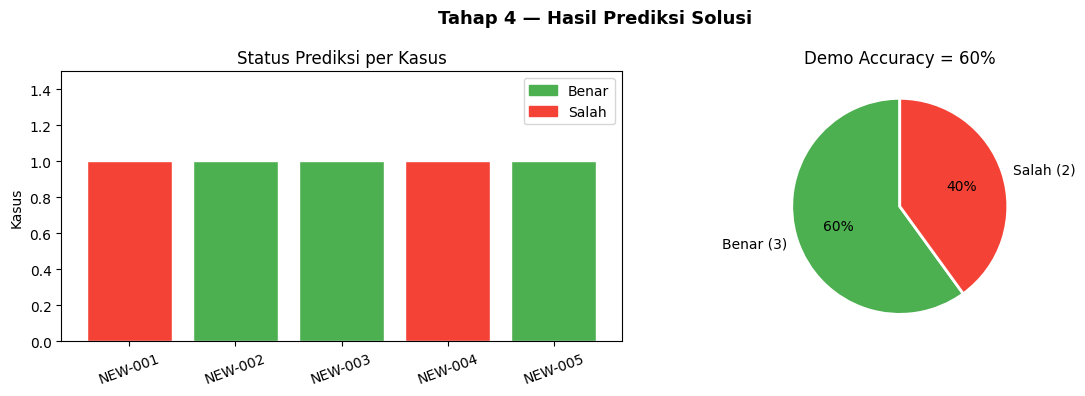

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Tahap 4 — Hasil Prediksi Solusi', fontsize=13, fontweight='bold')

# Perbandingan predicted vs actual per kasus
colors = ['#4CAF50' if m else '#F44336' for m in pred_df['match']]
axes[0].bar(pred_df['query_id'], [1]*len(pred_df), color=colors, edgecolor='white')
axes[0].set_title('Status Prediksi per Kasus')
axes[0].set_ylabel('Kasus')
axes[0].set_ylim(0, 1.5)
correct_patch = plt.Rectangle((0,0),1,1, color='#4CAF50', label='Benar')
wrong_patch   = plt.Rectangle((0,0),1,1, color='#F44336', label='Salah')
axes[0].legend(handles=[correct_patch, wrong_patch])
axes[0].tick_params(axis='x', rotation=20)

# Accuracy pie
correct = pred_df['match'].sum()
axes[1].pie([correct, len(pred_df)-correct],
            labels=[f'Benar ({correct})', f'Salah ({len(pred_df)-correct})'],
            colors=['#4CAF50','#F44336'],
            autopct='%1.0f%%', startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title(f'Demo Accuracy = {acc:.0%}')

plt.tight_layout()
plt.savefig('data/eval/tahap4_prediksi.png', dpi=120, bbox_inches='tight')
plt.show()

## 4.6 Output Tahap 4

| Output | Lokasi |
|--------|--------|
| Prediksi solusi | `data/results/predictions.csv` |

Kolom `predictions.csv`:
```
query_id | predicted_solution | representative_amar | actual_label | match | top_5_case_ids
```

✅ **Tahap 4 Selesai** — Lanjut ke `Tahap5_Model_Evaluation.ipynb`